# Entrenar el VAE en Colab Pro (desde la extensión "Colab" de VSCode)

Este notebook corre el pipeline de `scripts/preprocess_vae.py` + `scripts/VAE.py`
contra un runtime remoto de **Google Colab Pro**, conectado directamente desde
VSCode con la extensión oficial **"Colab"** (publisher: Google) - sin salir del
editor. Guía completa en el `README.md`, sección *"Alternativa: entrenar el VAE
en Colab Pro desde VSCode"*.

**Antes de correr este notebook:**
1. Instala la extensión **Colab** en VSCode (`Ctrl+Shift+X` -Z buscar "Colab").
2. Inicia sesión con la cuenta de Google que tiene Colab Pro.
3. En el selector de kernel (arriba a la derecha), elige el runtime **Colab**
   (no un intérprete local) y en `Runtime > Change runtime type` selecciona GPU.

Luego corre las celdas de este notebook en orden.

In [1]:
import os

REPO_URL = "https://github.com/Tamaracarrasco/AS4501-Proyect.git"
REPO_DIR = "/content/AS4501-Proyect"
BRANCH = "norm_sign"   # rama con la grilla UMAP y las curvas de loss (no esta en master)

if not os.path.isdir(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
!git checkout {BRANCH}
!git pull origin {BRANCH}


Cloning into '/content/AS4501-Proyect'...
remote: Enumerating objects: 413, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 413 (delta 105), reused 161 (delta 64), pack-reused 209 (from 1)
Receiving objects: 100% (413/413), 53.13 MiB | 36.61 MiB/s, done.
Resolving deltas: 100% (192/192), done.
/content/AS4501-Proyect
Already on 'norm_sign'
Your branch is up to date with 'origin/norm_sign'.
From https://github.com/Tamaracarrasco/AS4501-Proyect
 * branch            norm_sign  -> FETCH_HEAD
Already up to date.


## Dependencias

`requirements.txt` fija una build **CPU** de torch (`torch==2.12.0+cpu`), pensada
para correr localmente. Colab ya trae preinstalado un torch con soporte CUDA
funcionando con la GPU del runtime - si lo pisamos con la versión CPU del
`requirements.txt`, perdemos la GPU. Por eso instalamos todo *excepto* las líneas
de torch/torchvision.

In [2]:
!grep -v -i '^torch' requirements.txt > /tmp/requirements_colab.txt
# !pip install -q -r /tmp/requirements_colab.txt


In [3]:
!pip install -q torchmetrics umap-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.8 MB/s eta 0:00:00 0:00:01


## Verificar GPU

`VAE.py` detecta CUDA automáticamente (no hay que tocar el código ni el CONFIG).

In [4]:
!nvidia-smi

import torch
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Mon Jul 13 18:04:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Datos: montar Drive

Los archivos de `/data/` (el tar de stamps y el CSV de features) pesan varios GB
y no están en GitHub - se suben una vez a Google Drive y se montan en cada
sesión. Ajusta `DRIVE_DATA_DIR` a la carpeta real dentro de tu Drive.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# --- AJUSTA esta ruta a donde tengas los datos en tu Drive ---
DRIVE_DATA_DIR = "/content/drive/MyDrive/data_astroinf"

os.environ["COSMOS_TAR"] = f"{DRIVE_DATA_DIR}/cosmos_TC_202602.tar.gz.part_aa"
os.environ["COSMOS_FEATURES"] = f"{DRIVE_DATA_DIR}/features_images_20260707.csv"

print(os.environ["COSMOS_TAR"])
print(os.environ["COSMOS_FEATURES"])


Mounted at /content/drive
/content/drive/MyDrive/data_astroinf/cosmos_TC_202602.tar.gz.part_aa
/content/drive/MyDrive/data_astroinf/features_images_20260707.csv


## Salidas persistentes en Drive

El runtime de Colab es efímero (se borra al desconectar). `preprocess_vae.py`
y `VAE.py` escriben siempre en `<repo>/file_out_data/` (sin flag para cambiar la
ruta); para no perder el `.npz`, los checkpoints y las figuras entre sesiones,
apuntamos esa carpeta a Drive con un symlink, hecho una sola vez por sesión.

In [6]:
DRIVE_OUT_DIR = "/content/drive/MyDrive/data_astroinf/file_out_data"
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

LOCAL_OUT_DIR = f"{REPO_DIR}/file_out_data"
if os.path.islink(LOCAL_OUT_DIR) or os.path.exists(LOCAL_OUT_DIR):
    !rm -rf {LOCAL_OUT_DIR}
!ln -s {DRIVE_OUT_DIR} {LOCAL_OUT_DIR}

print(f"{LOCAL_OUT_DIR} -> {DRIVE_OUT_DIR}")


/content/AS4501-Proyect/file_out_data -> /content/drive/MyDrive/data_astroinf/file_out_data


## Preprocesamiento → `file_out_data/vae_input.npz`

Aplica los filtros de catálogo, la corrección por extinción galáctica, la
normalización "otro" (signed sqrt scaling) y el split train/val/test
estratificado. Con la GPU de Colab esto sigue corriendo en CPU (es I/O y NumPy),
pero solo hay que hacerlo una vez por conjunto de datos: el `.npz` queda en
Drive y se reutiliza entre sesiones.

In [7]:
# prueba rápida (carga solo 300 stamps, para validar que el pipeline corre):
# !python scripts/preprocess_vae.py --n-max 300

# corrida completa:
!python scripts/preprocess_vae.py


Tar: /content/drive/MyDrive/data_astroinf/cosmos_TC_202602.tar.gz.part_aa
Features: /content/drive/MyDrive/data_astroinf/features_images_20260707.csv

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287

Cargando stamps...
  (tar truncado: recuperados 21287 stamps antes del corte)
  stamps leídos (tras filtro de id): 21287
  descartados por NaN              : 2
  stamps válidos                   : 21285

Muestra final alineada: N=21285, X.shape=(21285, 5, 4, 30, 30)
Stamps corregidos por extinción galáctica (mw_transmission por banda).
Split  train/val/test: 17028/2128/2129 (estratificado por tipo morfológico)

Normalizado (otro: signed sqrt scaling). rango global: [-0.00, 0.96], media train≈0.000

Guardado: /content/AS4501-Proyect/file_out_data/vae_input.npz
          /content/AS4501-Proyect/file_out_data/vae_input_config.json


## Entrenamiento del VAE

Corre con la config por defecto (`z_dim=64`, 200 épocas) o con overrides por
CLI. `run_id` se auto-incrementa mirando `vae_summary*.json` en `file_out_data/`
(en Drive), así que corridas de sesiones distintas no se pisan entre sí.

In [8]:
!python scripts/VAE.py --epochs 100 --z-dim 64

# overrides comunes:
# !python scripts/VAE.py --epochs 100 --z-dim 32 --beta-final 0.5
# !python scripts/VAE.py --wandb                    # dashboard en vivo (requiere login de wandb)
# !python scripts/VAE.py --sweep                     # barrido con scripts/parameters_vae.dat


2026-07-13 18:08:46.579573: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda | seed: 42 | umap: True | wandb: True | torchmetrics: True
train=17028  val=2128
modelo: 3.65M params | share_level_weights=True
run_id: 3
[logger] escrito /content/AS4501-Proyect/file_out_data/vae3.input
e001 | beta=0.033 | train tot=395.6 rec=391.6 kl=119.1 | val tot=55.8 rec=31.7 kl=24.1 | act=64/64 ssim=nan
e002 | beta=0.067 | train tot=11.1 rec=10.2 kl=14.5 | val tot=163.1 rec=72.7 kl=90.4 | act=64/64 ssim=nan
e003 | beta=0.100 | train tot=7.0 rec=6.3 kl=7.1 | val tot=7.7 rec=5.9 kl=1.8 | act=58/64 ssim=nan
e004 | beta=0.133 | train tot=4.6 rec=4.4 kl=1.5 | val tot=5.3 rec=4.5 kl=0.8 | act=31/64 ssim=nan
e005 | beta=0.167 | train tot=4.7 rec=4.5 kl=0.9 |

## Visualizar el último resultado

Muestra la figura de reconstrucción más reciente de la última corrida (`run_id` más alto).

corrida: /content/drive/MyDrive/data_astroinf/file_out_data/figures/vae3


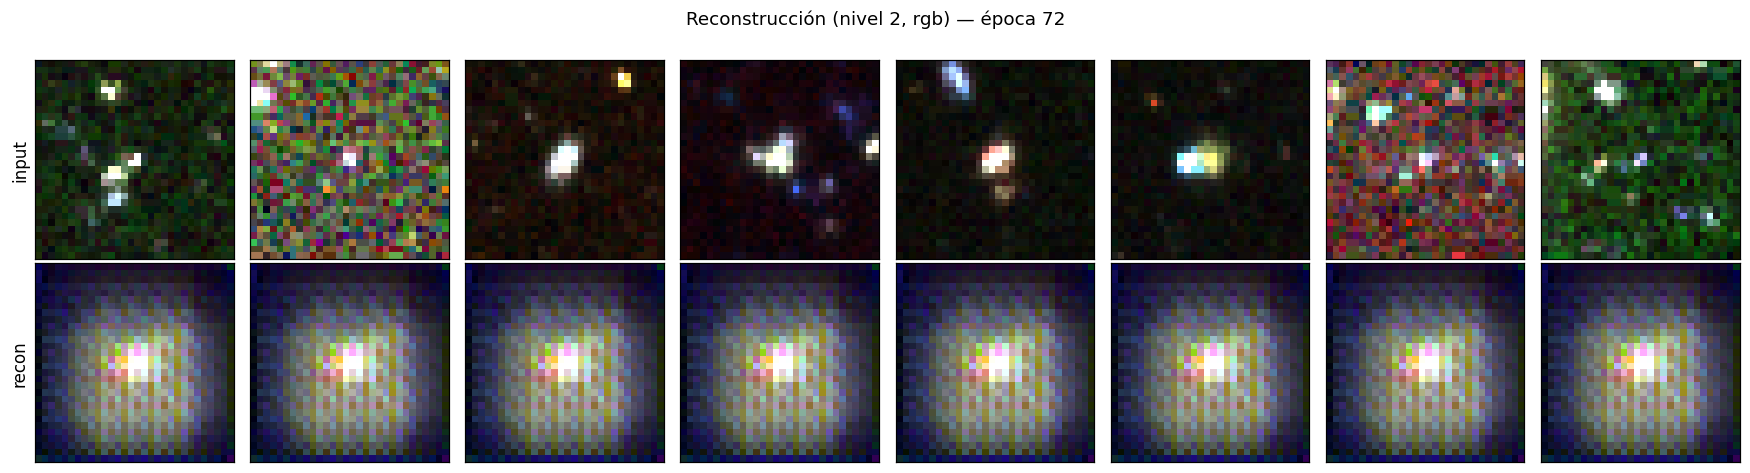

In [9]:
import glob
from IPython.display import Image, display

run_dirs = sorted(
    glob.glob(f"{DRIVE_OUT_DIR}/figures/vae*"),
    key=lambda p: int(p.rsplit("vae", 1)[-1]) if p.rsplit("vae", 1)[-1].isdigit() else -1,
)

if run_dirs:
    latest_run = run_dirs[-1]
    recon_imgs = sorted(glob.glob(f"{latest_run}/recon_e*.png"))
    if recon_imgs:
        print(f"corrida: {latest_run}")
        display(Image(filename=recon_imgs[-1]))
    else:
        print(f"sin figuras de reconstrucción todavía en {latest_run}")
else:
    print("todavía no hay corridas en", DRIVE_OUT_DIR)


## Curvas de loss y sensibilidad UMAP

`plot_loss_curves` se guarda cada `fig_every` épocas (recon y KL, train vs val).
`latent_umap_grid` es cara (un fit de UMAP por combinación de hiperparámetros),
así que solo se genera **una vez, al final, sobre la mejor época** — junto con
el UMAP simple (`umap_e*.png`). Los valores de `n_neighbors`/`min_dist` que
se barren están en `CONFIG["umap_n_neighbors_grid"]` / `["umap_min_dist_grid"]`
(default 3x3); para probar otros valores, edita esas listas en `scripts/VAE.py`
antes de correr el entrenamiento — no hay flag de CLI para esto todavía.

In [31]:
loss_imgs = sorted(glob.glob(f"{latest_run}/loss_curves_e*.png"))
if loss_imgs:
    display(Image(filename=loss_imgs[-1]))
else:
    print("sin curvas de loss todavía (se generan cada fig_every épocas)")


sin curvas de loss todavía (se generan cada fig_every épocas)


In [32]:
umap_grid_imgs = sorted(glob.glob(f"{latest_run}/umap_grid_e*.png"))
if umap_grid_imgs:
    display(Image(filename=umap_grid_imgs[-1]))
else:
    print("sin grilla UMAP todavía (se genera una sola vez, al final del entrenamiento, "
          "y requiere umap-learn instalado)")


sin grilla UMAP todavía (se genera una sola vez, al final del entrenamiento, y requiere umap-learn instalado)


## Siguientes pasos

- Todo lo relevante (`vae_metrics{N}.csv`, `vae_summary{N}.json`, `figures/vae{N}/`,
  `checkpoints/vae_best{N}.pt`, `vae{N}.input`) ya quedó en
  `DRIVE_OUT_DIR` gracias al symlink - no se pierde al cerrar el runtime.
- Para compartirlo con el equipo vía git: copia (o descarga) esos archivos desde
  Drive a tu clon local de `file_out_data/` y comitea desde ahí - evita comitear
  directo desde el runtime efímero de Colab.